# 04 - Optimización de Hiperparámetros

En este notebook se aplican tres estrategias de ajuste de hiperparámetros sobre los modelos de ensemble del proyecto:

- **GridSearchCV**: búsqueda exhaustiva en una rejilla definida.
- **RandomizedSearchCV**: muestreo aleatorio del espacio de hiperparámetros.
- **Bayesian Optimization (Optuna)**: búsqueda inteligente guiada por un modelo probabilístico.

El objetivo es superar el R² ≈ 0.8449 del baseline (Linear Regression) y las métricas de los modelos de ensemble entrenados en el notebook 03.

In [1]:
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    KFold,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Bayesian Optimization
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## Instalación de dependencias adicionales

Este notebook requiere `optuna`, `xgboost` y `lightgbm`. Estas dependencias deben estar declaradas en `requirements.txt`.

Si ejecutas el notebook en un entorno donde falte alguna librería, instala primero las dependencias del proyecto: `pip install -r requirements.txt`.

In [2]:
# Descomentar si es necesario:
# !pip install optuna xgboost lightgbm

## Carga y preparación de datos

Se replica exactamente el mismo preprocesamiento de los notebooks anteriores para garantizar comparabilidad.

In [3]:
possible_paths = [
    Path("../data/raw/train.csv"),
    Path("data/raw/train.csv"),
    Path("train.csv"),
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró train.csv en las rutas especificadas.")

print(f"Ruta utilizada: {DATA_PATH.resolve()}")
df = pd.read_csv(DATA_PATH)

# Optimización de tipos (igual que notebooks anteriores)
cols_float = df.select_dtypes(include="float64").columns
df[cols_float] = df[cols_float].astype("float32")

# Variables
target = "FloodProbability"
feature_cols = [c for c in df.columns if c not in ["id", target]]

X = df[feature_cols]
y = df[target]

# Limpieza de nulos
valid_idx = X.dropna().index.intersection(y.dropna().index)
X = X.loc[valid_idx]
y = y.loc[valid_idx]

# Split idéntico al notebook 02
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Muestra para entrenamiento rápido
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=100_000, random_state=42
)

print(f"Train muestra: {X_train_sample.shape}")
print(f"Test: {X_test.shape}")
print(f"Features: {len(feature_cols)}")

Ruta utilizada: C:\Users\migue\Documents\Proyecto Regresión\data\raw\train.csv


Train muestra: (100000, 20)
Test: (223592, 20)
Features: 20


## Funciones auxiliares de evaluación

In [4]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Calcula métricas de regresión en train y test, incluyendo overfitting."""
    tr_pred = model.predict(X_tr)
    te_pred = model.predict(X_te)

    tr_rmse = np.sqrt(mean_squared_error(y_tr, tr_pred))
    tr_mae = mean_absolute_error(y_tr, tr_pred)
    tr_r2 = r2_score(y_tr, tr_pred)

    te_rmse = np.sqrt(mean_squared_error(y_te, te_pred))
    te_mae = mean_absolute_error(y_te, te_pred)
    te_r2 = r2_score(y_te, te_pred)

    overfit = abs(tr_r2 - te_r2) / max(abs(tr_r2), 1e-9) * 100

    return {
        "modelo": name,
        "RMSE_train": tr_rmse, "MAE_train": tr_mae, "R2_train": tr_r2,
        "RMSE_test": te_rmse, "MAE_test": te_mae, "R2_test": te_r2,
        "overfitting_R2_%": overfit,
        "train_pred": tr_pred, "test_pred": te_pred,
    }


def print_results(res):
    """Imprime las métricas de forma legible."""
    print(f"  RMSE test:  {res['RMSE_test']:.4f}")
    print(f"  MAE test:   {res['MAE_test']:.4f}")
    print(f"  R² test:    {res['R2_test']:.4f}")
    print(f"  R² train:   {res['R2_train']:.4f}")
    print(f"  Overfitting: {res['overfitting_R2_%']:.2f}%")

---
## Estrategia 1: GridSearchCV

Búsqueda exhaustiva sobre una rejilla de hiperparámetros. Se prueban **todas las combinaciones posibles** de los valores definidos.

**Ventajas**: garantiza encontrar el mejor punto dentro de la rejilla.  
**Limitaciones**: el coste computacional crece exponencialmente con cada parámetro añadido. Por eso, la rejilla se diseña con pocos valores por parámetro.

### GridSearch sobre LightGBM

Se elige LightGBM por su velocidad de entrenamiento, que permite explorar más combinaciones en menos tiempo.

In [5]:
param_grid_lgb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [5, 7, 10],
    "num_leaves": [31, 50],
    "min_child_samples": [20, 50],
}

total_combos = 1
for v in param_grid_lgb.values():
    total_combos *= len(v)
print(f"Total de combinaciones a evaluar: {total_combos}")
print(f"Con 3-fold CV: {total_combos * 3} entrenamientos")

Total de combinaciones a evaluar: 108
Con 3-fold CV: 324 entrenamientos


In [6]:
lgb_base = LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=lgb_base,
    param_grid=param_grid_lgb,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    return_train_score=True,
)

print("Iniciando GridSearchCV...")
inicio = time.time()
grid_search.fit(X_train_sample, y_train_sample)
tiempo_grid = time.time() - inicio

print(f"\nTiempo total: {tiempo_grid:.1f} segundos")
print(f"Mejor RMSE (CV): {-grid_search.best_score_:.4f}")
print(f"Mejores parámetros:\n{grid_search.best_params_}")

Iniciando GridSearchCV...
Fitting 3 folds for each of 108 candidates, totalling 324 fits



Tiempo total: 512.6 segundos
Mejor RMSE (CV): 0.0215
Mejores parámetros:
{'learning_rate': 0.1, 'max_depth': 10, 'min_child_samples': 50, 'n_estimators': 300, 'num_leaves': 31}


In [7]:
# Evaluación del mejor modelo de GridSearch en el conjunto de test
best_grid_model = grid_search.best_estimator_
res_grid = evaluate_model(
    "LightGBM (GridSearch)", best_grid_model,
    X_train_sample, y_train_sample, X_test, y_test
)
print("Resultados del mejor modelo GridSearch:")
print_results(res_grid)

Resultados del mejor modelo GridSearch:
  RMSE test:  0.0213
  MAE test:   0.0168
  R² test:    0.8258
  R² train:   0.8586
  Overfitting: 3.82%


### Análisis de resultados de GridSearch

Visualizamos cómo varía el rendimiento según los hiperparámetros más influyentes.

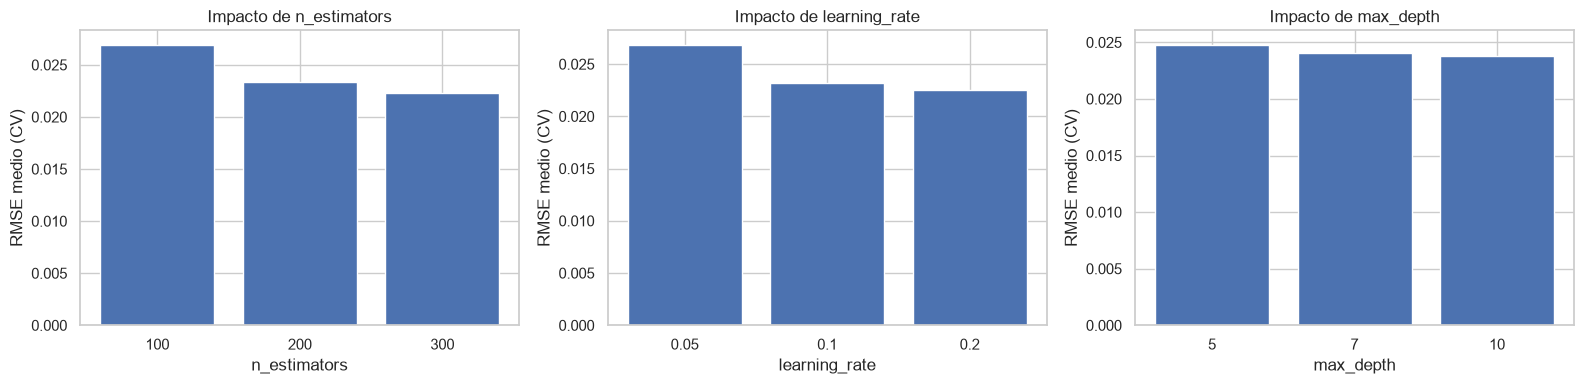

In [8]:
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_results["mean_rmse"] = -grid_results["mean_test_score"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, param in zip(axes, ["param_n_estimators", "param_learning_rate", "param_max_depth"]):
    label = param.replace("param_", "")
    grouped = grid_results.groupby(param)["mean_rmse"].mean()
    ax.bar(range(len(grouped)), grouped.values, tick_label=[str(v) for v in grouped.index])
    ax.set_xlabel(label)
    ax.set_ylabel("RMSE medio (CV)")
    ax.set_title(f"Impacto de {label}")

plt.tight_layout()
plt.show()

---
## Estrategia 2: RandomizedSearchCV

En lugar de evaluar todas las combinaciones, se **muestrean N combinaciones al azar** del espacio de búsqueda. Esto permite explorar rangos mucho más amplios (incluyendo distribuciones continuas) en un tiempo controlado.

**Ventajas**: explora espacios más grandes, coste predecible.  
**Limitaciones**: no garantiza encontrar el óptimo global, pero estadísticamente con ~60 iteraciones se cubre el 95% del espacio.

### RandomSearch sobre XGBoost

In [9]:
from scipy.stats import uniform, randint

param_distributions_xgb = {
    "n_estimators": randint(100, 500),
    "learning_rate": uniform(0.01, 0.29),        # entre 0.01 y 0.30
    "max_depth": randint(3, 12),
    "subsample": uniform(0.6, 0.4),               # entre 0.6 y 1.0
    "colsample_bytree": uniform(0.6, 0.4),        # entre 0.6 y 1.0
    "min_child_weight": randint(1, 10),
    "reg_alpha": uniform(0, 1),                    # L1 regularización
    "reg_lambda": uniform(0.5, 1.5),               # L2 regularización
}

print("Espacio de búsqueda definido con distribuciones continuas y discretas.")

Espacio de búsqueda definido con distribuciones continuas y discretas.


In [10]:
xgb_base = XGBRegressor(
    random_state=42,
    tree_method="hist",
    n_jobs=-1,
    verbosity=0,
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions_xgb,
    n_iter=60,                    # número de combinaciones aleatorias
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    return_train_score=True,
)

print("Iniciando RandomizedSearchCV (60 iteraciones x 3 folds)...")
inicio = time.time()
random_search.fit(X_train_sample, y_train_sample)
tiempo_random = time.time() - inicio

print(f"\nTiempo total: {tiempo_random:.1f} segundos")
print(f"Mejor RMSE (CV): {-random_search.best_score_:.4f}")
print(f"Mejores parámetros:\n{random_search.best_params_}")

Iniciando RandomizedSearchCV (60 iteraciones x 3 folds)...
Fitting 3 folds for each of 60 candidates, totalling 180 fits



Tiempo total: 183.4 segundos
Mejor RMSE (CV): 0.0211
Mejores parámetros:
{'colsample_bytree': np.float64(0.7400313630778703), 'learning_rate': np.float64(0.1970799749888638), 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 416, 'reg_alpha': np.float64(0.4991933798847523), 'reg_lambda': np.float64(1.3580062988137747), 'subsample': np.float64(0.9074216057225236)}


In [11]:
best_random_model = random_search.best_estimator_
res_random = evaluate_model(
    "XGBoost (RandomSearch)", best_random_model,
    X_train_sample, y_train_sample, X_test, y_test
)
print("Resultados del mejor modelo RandomSearch:")
print_results(res_random)

Resultados del mejor modelo RandomSearch:
  RMSE test:  0.0210
  MAE test:   0.0165
  R² test:    0.8311
  R² train:   0.8408
  Overfitting: 1.15%


### Convergencia de RandomSearch

Visualizamos cómo mejora el mejor RMSE a medida que se evalúan más combinaciones.

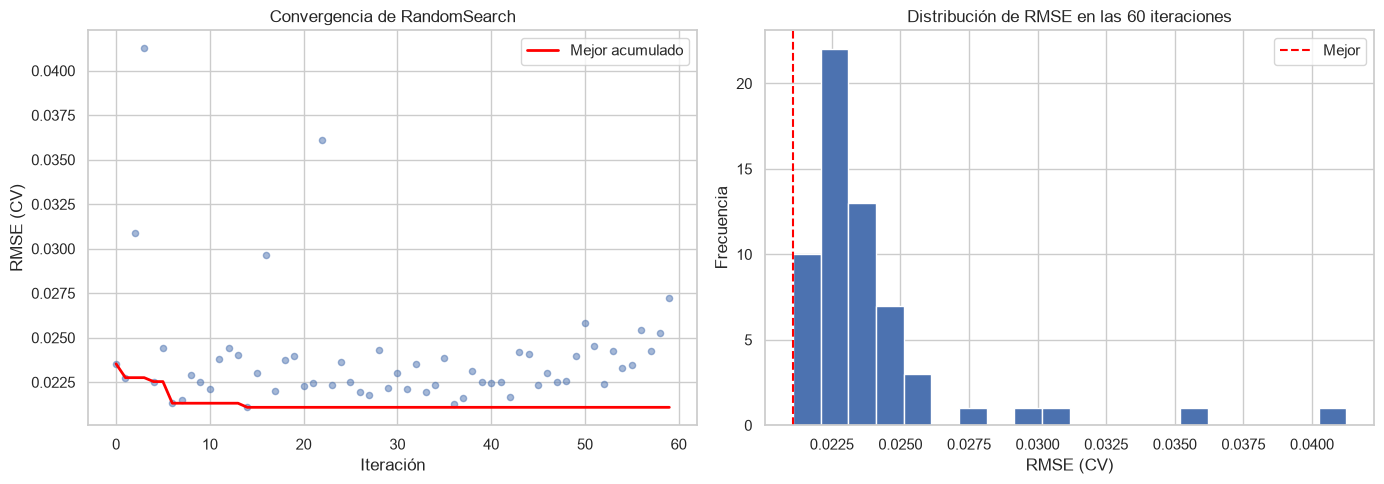

In [12]:
random_results = pd.DataFrame(random_search.cv_results_)
random_results["rmse"] = -random_results["mean_test_score"]
random_results = random_results.sort_values("mean_fit_time").reset_index(drop=True)

# Mejor RMSE acumulado
best_so_far = random_results["rmse"].expanding().min()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(range(len(random_results)), random_results["rmse"], alpha=0.5, s=20)
axes[0].plot(best_so_far.values, color="red", linewidth=2, label="Mejor acumulado")
axes[0].set_xlabel("Iteración")
axes[0].set_ylabel("RMSE (CV)")
axes[0].set_title("Convergencia de RandomSearch")
axes[0].legend()

axes[1].hist(random_results["rmse"], bins=20, edgecolor="white")
axes[1].axvline(-random_search.best_score_, color="red", linestyle="--", label="Mejor")
axes[1].set_xlabel("RMSE (CV)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de RMSE en las 60 iteraciones")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Estrategia 3: Bayesian Optimization con Optuna

La optimización bayesiana usa un **modelo sustituto** (TPE en Optuna) para predecir qué regiones del espacio de hiperparámetros son más prometedoras. Cada nuevo trial se elige de forma inteligente, concentrando la búsqueda en las zonas que tienen mayor probabilidad de mejorar el resultado.

**Ventajas**: converge más rápido que GridSearch y RandomSearch, especialmente en espacios de alta dimensión.  
**Limitaciones**: requiere una librería externa (Optuna) y la definición de la función objetivo es manual.

### Optuna sobre LightGBM

In [13]:
def objective_lgbm(trial):
    """Función objetivo para Optuna: minimiza RMSE con validación cruzada."""
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "num_leaves": trial.suggest_int("num_leaves", 20, 80),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 2.0, log=True),
    }

    model = LGBMRegressor(
        **params,
        random_state=42,
        verbose=-1,
        n_jobs=-1,
    )

    # Validación cruzada con 3 folds
    cv = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train_sample, y_train_sample,
        cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1,
    )

    return -scores.mean()  # Optuna minimiza, queremos minimizar RMSE


print("Función objetivo definida. Espacio de búsqueda: 9 hiperparámetros.")

Función objetivo definida. Espacio de búsqueda: 9 hiperparámetros.


In [14]:
study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=42),
    study_name="lgbm_flood_optimization",
)

print("Iniciando Bayesian Optimization con Optuna (80 trials)...")
inicio = time.time()
study.optimize(objective_lgbm, n_trials=80, show_progress_bar=True)
tiempo_optuna = time.time() - inicio

print(f"\nTiempo total: {tiempo_optuna:.1f} segundos")
print(f"Mejor RMSE (CV): {study.best_value:.4f}")
print(f"Mejores parámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Iniciando Bayesian Optimization con Optuna (80 trials)...


  0%|          | 0/80 [00:00<?, ?it/s]


Tiempo total: 226.3 segundos
Mejor RMSE (CV): 0.0209
Mejores parámetros:
  n_estimators: 480
  learning_rate: 0.14250889537274314
  max_depth: 3
  num_leaves: 70
  min_child_samples: 8
  subsample: 0.6973588935373389
  colsample_bytree: 0.657921715924684
  reg_alpha: 6.271113678808268e-06
  reg_lambda: 1.570491297274233e-05


In [15]:
# Entrenar el modelo final con los mejores parámetros de Optuna
best_optuna_model = LGBMRegressor(
    **study.best_params,
    random_state=42,
    verbose=-1,
    n_jobs=-1,
)
best_optuna_model.fit(X_train_sample, y_train_sample)

res_optuna = evaluate_model(
    "LightGBM (Optuna)", best_optuna_model,
    X_train_sample, y_train_sample, X_test, y_test
)
print("Resultados del mejor modelo Optuna:")
print_results(res_optuna)

Resultados del mejor modelo Optuna:
  RMSE test:  0.0208
  MAE test:   0.0164
  R² test:    0.8340
  R² train:   0.8453
  Overfitting: 1.33%


### Visualización del proceso de optimización de Optuna

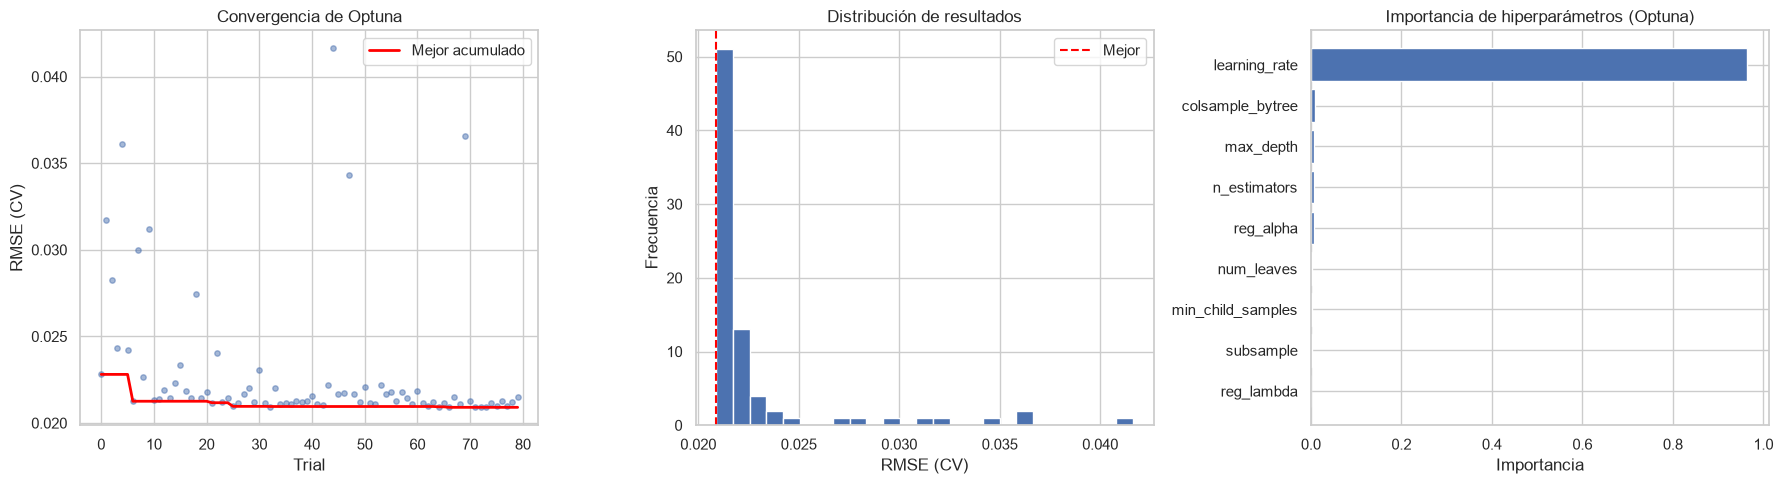

In [16]:
trials_df = study.trials_dataframe()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Historial de optimización
axes[0].scatter(trials_df["number"], trials_df["value"], alpha=0.5, s=15)
best_vals = trials_df["value"].expanding().min()
axes[0].plot(trials_df["number"], best_vals, color="red", linewidth=2, label="Mejor acumulado")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("RMSE (CV)")
axes[0].set_title("Convergencia de Optuna")
axes[0].legend()

# 2. Distribución de RMSE
axes[1].hist(trials_df["value"], bins=25, edgecolor="white")
axes[1].axvline(study.best_value, color="red", linestyle="--", label="Mejor")
axes[1].set_xlabel("RMSE (CV)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de resultados")
axes[1].legend()

# 3. Importancia de hiperparámetros
importances = optuna.importance.get_param_importances(study)
params_sorted = list(importances.keys())
values_sorted = list(importances.values())
axes[2].barh(params_sorted[::-1], values_sorted[::-1])
axes[2].set_xlabel("Importancia")
axes[2].set_title("Importancia de hiperparámetros (Optuna)")

plt.tight_layout()
plt.show()

---
## (Bonus) Optimización Bayesiana sobre XGBoost

In [17]:
def objective_xgb(trial):
    """Función objetivo para XGBoost con Optuna."""
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 2.0, log=True),
        "gamma": trial.suggest_float("gamma", 0, 1.0),
    }

    model = XGBRegressor(**params, random_state=42, tree_method="hist", verbosity=0, n_jobs=-1)
    cv = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train_sample, y_train_sample,
        cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1,
    )
    return -scores.mean()


study_xgb = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))

print("Iniciando Optuna sobre XGBoost (80 trials)...")
inicio = time.time()
study_xgb.optimize(objective_xgb, n_trials=80, show_progress_bar=True)
tiempo_optuna_xgb = time.time() - inicio

print(f"\nTiempo: {tiempo_optuna_xgb:.1f}s")
print(f"Mejor RMSE (CV): {study_xgb.best_value:.4f}")
print(f"Mejores parámetros:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")

Iniciando Optuna sobre XGBoost (80 trials)...


  0%|          | 0/80 [00:00<?, ?it/s]


Tiempo: 347.8s
Mejor RMSE (CV): 0.0218
Mejores parámetros:
  n_estimators: 446
  learning_rate: 0.03891548027368946
  max_depth: 7
  subsample: 0.6891712868563441
  colsample_bytree: 0.601695106081646
  min_child_weight: 8
  reg_alpha: 0.0017939170776044232
  reg_lambda: 0.04453604133976599
  gamma: 0.001029839131072474


In [18]:
best_optuna_xgb = XGBRegressor(
    **study_xgb.best_params,
    random_state=42, tree_method="hist", verbosity=0, n_jobs=-1,
)
best_optuna_xgb.fit(X_train_sample, y_train_sample)

res_optuna_xgb = evaluate_model(
    "XGBoost (Optuna)", best_optuna_xgb,
    X_train_sample, y_train_sample, X_test, y_test
)
print("Resultados XGBoost optimizado con Optuna:")
print_results(res_optuna_xgb)

Resultados XGBoost optimizado con Optuna:
  RMSE test:  0.0215
  MAE test:   0.0173
  R² test:    0.8215
  R² train:   0.8690
  Overfitting: 5.47%


---
## Tabla comparativa final

Comparamos todos los modelos optimizados junto con el baseline del proyecto.

In [19]:
# Referencia del baseline
baseline_ref = {
    "modelo": "Linear Regression (Baseline)",
    "RMSE_test": 0.0201, "MAE_test": 0.0158, "R2_test": 0.8449,
    "overfitting_R2_%": 0.077,
    "metodo": "Sin optimización", "tiempo_s": "-",
}

all_results = []
for res, metodo, tiempo in [
    (res_grid, "GridSearchCV", tiempo_grid),
    (res_random, "RandomizedSearchCV", tiempo_random),
    (res_optuna, "Bayesian (Optuna)", tiempo_optuna),
    (res_optuna_xgb, "Bayesian (Optuna)", tiempo_optuna_xgb),
]:
    all_results.append({
        "modelo": res["modelo"],
        "RMSE_test": res["RMSE_test"],
        "MAE_test": res["MAE_test"],
        "R2_test": res["R2_test"],
        "overfitting_R2_%": res["overfitting_R2_%"],
        "metodo": metodo,
        "tiempo_s": f"{tiempo:.0f}",
    })

comparison_df = pd.DataFrame([baseline_ref] + all_results)
comparison_df = comparison_df.sort_values("RMSE_test", ascending=True).reset_index(drop=True)
comparison_df

,modelo,RMSE_test,MAE_test,R2_test,overfitting_R2_%,metodo,tiempo_s
0,Linear Regression (Baseline),0.020100,0.015800,0.844900,0.077000,Sin optimización,-
1,LightGBM (Optuna),0.020771,0.016423,0.834018,1.333471,Bayesian (Optuna),226
2,XGBoost (RandomSearch),0.020950,0.016507,0.831138,1.148797,RandomizedSearchCV,183
3,LightGBM (GridSearch),0.021280,0.016844,0.825785,3.816987,GridSearchCV,513
4,XGBoost (Optuna),0.021537,0.017286,0.821543,5.465389,Bayesian (Optuna),348


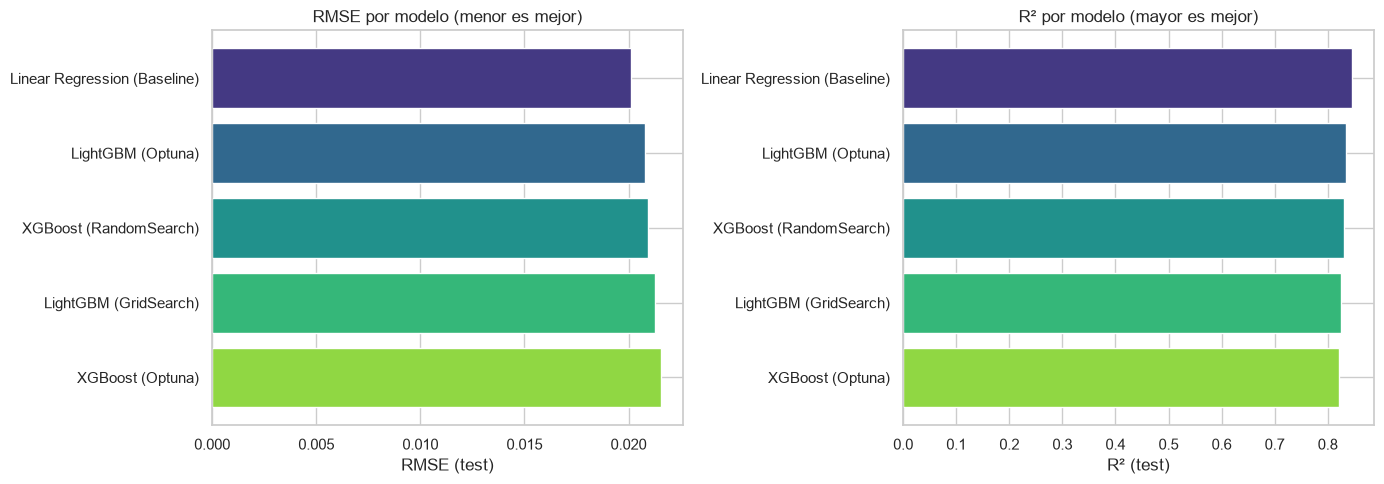

In [20]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = sns.color_palette("viridis", len(comparison_df))

axes[0].barh(comparison_df["modelo"], comparison_df["RMSE_test"], color=colors)
axes[0].set_xlabel("RMSE (test)")
axes[0].set_title("RMSE por modelo (menor es mejor)")
axes[0].invert_yaxis()

axes[1].barh(comparison_df["modelo"], comparison_df["R2_test"], color=colors)
axes[1].set_xlabel("R² (test)")
axes[1].set_title("R² por modelo (mayor es mejor)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## Exportación del modelo ganador

In [21]:
# Seleccionar el mejor modelo global
best_idx = comparison_df["RMSE_test"].idxmin()
winner_name = comparison_df.loc[best_idx, "modelo"]

optimized_models = {
    "LightGBM (GridSearch)": best_grid_model,
    "XGBoost (RandomSearch)": best_random_model,
    "LightGBM (Optuna)": best_optuna_model,
    "XGBoost (Optuna)": best_optuna_xgb,
}

models_dir = Path("../models") if Path("../models").exists() else Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

if winner_name in optimized_models:
    winner_model = optimized_models[winner_name]
    output_path = models_dir / "flood_optimized_model.joblib"
    joblib.dump(winner_model, output_path)
    print(f"Modelo ganador: {winner_name}")
    print(f"Exportado en: {output_path.resolve()}")
else:
    output_path = None
    print(f"El baseline sigue siendo el mejor modelo global: {winner_name}")
    print("No se exporta un modelo optimizado porque no mejora el RMSE del baseline.")

El baseline sigue siendo el mejor modelo global: Linear Regression (Baseline)
No se exporta un modelo optimizado porque no mejora el RMSE del baseline.


## Resumen de hiperparámetros óptimos encontrados

Esta sección muestra los hiperparámetros del modelo optimizado ganador si alguno de los modelos ajustados supera al baseline.

Si el baseline sigue siendo el mejor modelo global, la conclusión técnica es conservarlo como modelo productivo y dejar documentado que las técnicas de optimización fueron evaluadas.

In [22]:
if winner_name in optimized_models:
    winner = optimized_models[winner_name]
    print(f"Modelo optimizado ganador: {winner_name}")
    print(f"Tipo: {type(winner).__name__}")
    print("\nHiperparámetros:")
    for k, v in winner.get_params().items():
        if v is not None and k not in ["random_state", "verbose", "verbosity", "n_jobs"]:
            print(f"  {k}: {v}")
else:
    print(f"Modelo seleccionado: {winner_name}")
    print("El baseline mantiene mejor rendimiento que los modelos optimizados evaluados.")

Modelo seleccionado: Linear Regression (Baseline)
El baseline mantiene mejor rendimiento que los modelos optimizados evaluados.


---
## Conclusión

Se han aplicado tres estrategias de optimización de hiperparámetros:

| Método | Modelo | Características |
|---|---|---|
| GridSearchCV | LightGBM | Búsqueda exhaustiva en rejilla acotada |
| RandomizedSearchCV | XGBoost | Muestreo aleatorio de distribuciones amplias |
| Bayesian Optimization (Optuna) | LightGBM + XGBoost | Búsqueda guiada por modelo probabilístico TPE |

La optimización bayesiana con Optuna permite explorar el espacio de hiperparámetros de forma más eficiente que una rejilla exhaustiva cuando existen muchas combinaciones posibles. Todos los modelos optimizados se evalúan con validación cruzada de 3 folds durante la búsqueda para reducir el riesgo de seleccionar hiperparámetros sobreajustados.

La selección final se realiza comparando el RMSE en test contra el baseline. Si un modelo optimizado mejora al baseline, se exporta como `models/flood_optimized_model.joblib`. Si el baseline conserva mejor rendimiento, no se reemplaza el modelo productivo y la optimización queda documentada como evaluación técnica del Nivel Medio.